In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cdflib
import sys

print("HelioSonic notebook is working.")
print("Python:", sys.executable)
print("NumPy:", np.__version__)

HelioSonic notebook is working.
Python: /opt/anaconda3/envs/heliosonic/bin/python
NumPy: 2.5.0


In [2]:
import cdflib
import numpy as np
import matplotlib.pyplot as plt

cdf = cdflib.CDF("../data/ac_h0_swe_20240709_v11.cdf")

cdf.cdf_info()
print(cdf.cdf_info())

info = cdf.cdf_info()

print("rVariables:", info.rVariables)
print("zVariables:", info.zVariables)

CDFInfo(CDF=PosixPath('/Users/alanhu/Desktop/HelioSonic_MAIN/data/ac_h0_swe_20240709_v11.cdf'), Version='3.7.1', Encoding=1, Majority='Column_major', rVariables=['Epoch', 'Time_PB5', 'unit_time', 'label_time', 'format_time', 'Np', 'Vp', 'Tpr', 'alpha_ratio', 'V_GSE', 'label_V_GSE', 'V_RTN', 'label_V_RTN', 'V_GSM', 'label_V_GSM', 'SC_pos_GSE', 'label_pos_GSE', 'SC_pos_GSM', 'label_pos_GSM'], zVariables=[], Attributes=[{'TITLE': 'Global'}, {'Project': 'Global'}, {'Discipline': 'Global'}, {'Source_name': 'Global'}, {'Data_type': 'Global'}, {'Descriptor': 'Global'}, {'Data_version': 'Global'}, {'Generated_by': 'Global'}, {'Generation_date': 'Global'}, {'LINK_TEXT': 'Global'}, {'LINK_TITLE': 'Global'}, {'HTTP_LINK': 'Global'}, {'TEXT': 'Global'}, {'MODS': 'Global'}, {'ADID_ref': 'Global'}, {'Logical_file_id': 'Global'}, {'Logical_source': 'Global'}, {'Logical_source_description': 'Global'}, {'PI_name': 'Global'}, {'PI_affiliation': 'Global'}, {'Mission_group': 'Global'}, {'Instrument_type':

In [3]:
import os

print(os.getcwd())


/Users/alanhu/Desktop/HelioSonic_MAIN/notebooks



Np
{'FIELDNAM': 'Proton No. density', 'VALIDMIN': np.float32(0.0), 'VALIDMAX': np.float32(200.0), 'SCALEMIN': np.float32(0.0), 'SCALEMAX': np.float32(100.0), 'LABLAXIS': 'H_Density', 'UNITS': '#/cc', 'VAR_TYPE': 'data', 'FORMAT': 'F8.4', 'FILLVAL': np.float32(-1e+31), 'DEPEND_0': 'Epoch', 'DICT_KEY': 'density>number', 'CATDESC': 'Solar Wind Proton Number Density, scalar', 'AVG_TYPE': ' ', 'DISPLAY_TYPE': 'time_series', 'VAR_NOTES': 'Np is the proton number density in units of cm-3, as calculated by integrating the ion distribution function.'}

Vp
{'FIELDNAM': 'Solar Wind Proton Speed', 'VALIDMIN': np.float32(0.0), 'VALIDMAX': np.float32(2000.0), 'SCALEMIN': np.float32(0.0), 'SCALEMAX': np.float32(1500.0), 'LABLAXIS': 'SW_H_Speed', 'UNITS': 'km/s', 'VAR_TYPE': 'data', 'FORMAT': 'f8.2', 'FILLVAL': np.float32(-1e+31), 'DEPEND_0': 'Epoch', 'DICT_KEY': 'velocity>speed', 'CATDESC': 'Solar Wind Bulk Speed', 'AVG_TYPE': ' ', 'DISPLAY_TYPE': 'time_series', 'VAR_NOTES': 'Vp is the solar wind pr

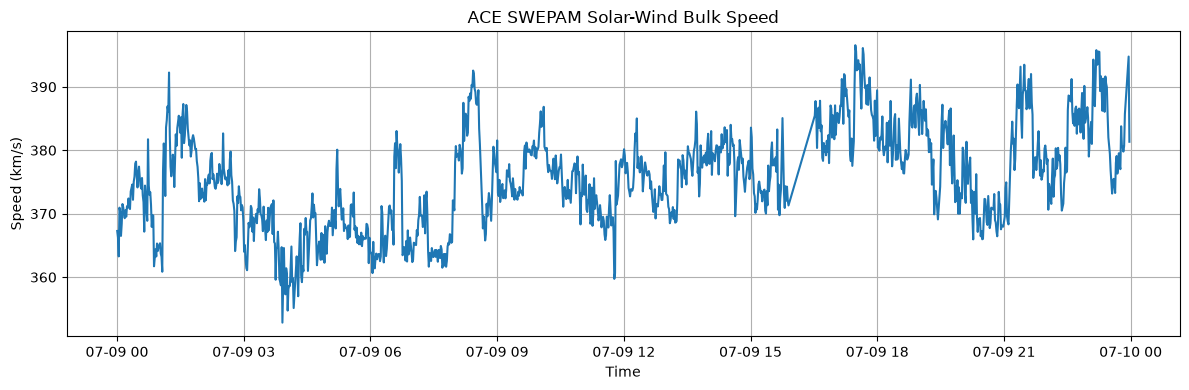

In [4]:
for var in ["Np", "Vp", "Tpr"]:
    print(f"\n{var}")
    print(cdf.varattsget(var))

epoch_raw = cdf.varget("Epoch")
speed = cdf.varget("Vp")

print("Number of timestamps:", len(epoch_raw))
print("Number of speed samples:", len(speed))
print("First five speed values:", speed[:5])

times = cdflib.cdfepoch.to_datetime(epoch_raw)

print(times[:5])

speed_atts = cdf.varattsget("Vp")
fill_value = speed_atts.get("FILLVAL")

mask = np.isfinite(speed)

if fill_value is not None:
    mask &= speed != fill_value

clean_times = times[mask]
clean_speed = speed[mask]

print("Valid samples:", len(clean_speed))

plt.figure(figsize=(12, 4))
plt.plot(clean_times, clean_speed)

plt.title("ACE SWEPAM Solar-Wind Bulk Speed")
plt.xlabel("Time")
plt.ylabel(f"Speed ({speed_atts.get('UNITS', 'unknown units')})")
plt.grid(True)
plt.tight_layout()
plt.show()
